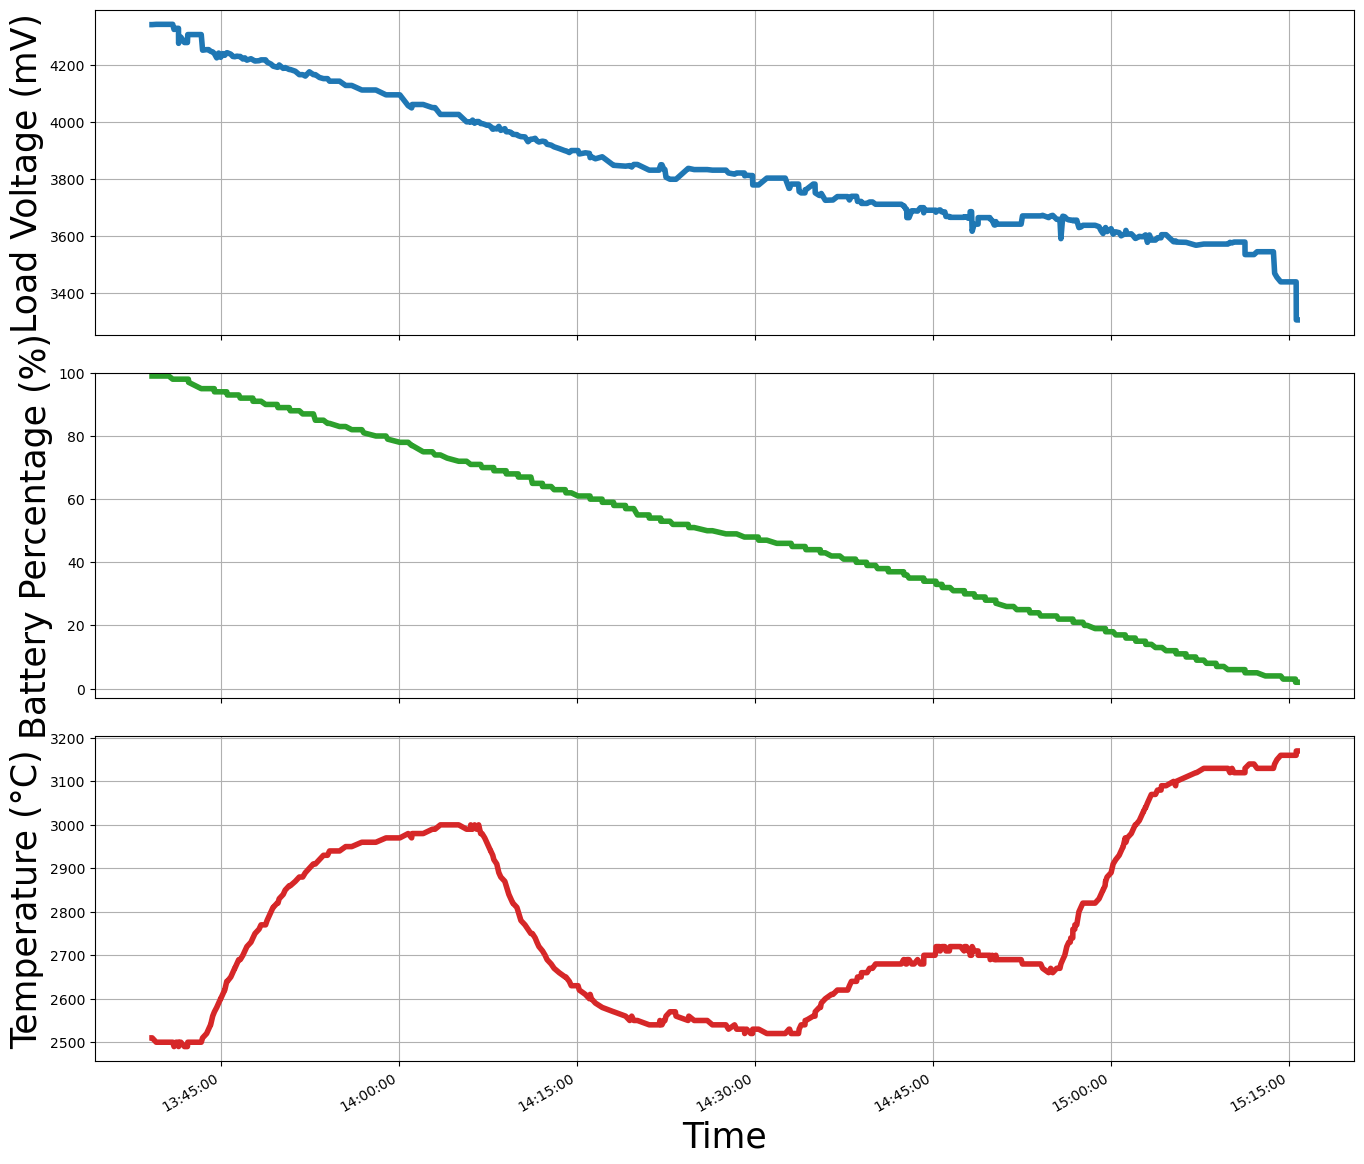

<Figure size 640x480 with 0 Axes>

In [1]:
import re
from datetime import datetime
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.dates as mdates

plt.style.use('default')
# --- User-defined time window ---
# Set the start and end time to filter the plot. Use 'HH:MM:SS' format.
# Set to None to include all data from the beginning or until the end.
start_time_str = "13:30:00"
end_time_str = "15:50:30"
# --- End of user settings ---

# Define the input file path
log_file_path = 'Full_Battery_logcat_RB_Display_Messenger_Wifi-D.txt'

# Lists to store the data
timestamps = []
voltages = []
percentages = []
temperatures = []

# --- CORRECTED REGEX ---
# This pattern now correctly matches the log file format.
log_pattern = re.compile(
    r'(\d{2}-\d{2}\s\d{2}:\d{2}:\d{2}\.\d{3}).*?'
    r'deviceBatteryDetails=Battery\(stateOfCharge=(\d+), isCharging=false, temperature=(\d+), voltage=(\d+)'
)

try:
    with open(log_file_path, 'r') as f:
        for line in f:
            match = log_pattern.search(line)
            if match:
                # Correctly unpack the captured groups
                timestamp_str, percentage_val, temp_val, voltage_val = match.groups()
                timestamp = datetime.strptime(f"2023-{timestamp_str}", '%Y-%m-%d %H:%M:%S.%f')
                
                timestamps.append(timestamp)
                percentages.append(int(percentage_val))
                voltages.append(int(voltage_val))
                # Temperature is in tenths of a degree, so divide by 10
                temperatures.append(int(temp_val) / 10)

    if not timestamps:
        print("No battery data was found in the log file matching the specified pattern.")
    else:
        # Create a pandas DataFrame
        df = pd.DataFrame({
            'Timestamp': pd.to_datetime(timestamps),
            'Voltage': voltages,
            'Percentage': percentages,
            'Temperature': temperatures
        })
        # Calculate elapsed time in seconds from the first timestamp
        df['Elapsed Time'] = (df['Timestamp'] - df['Timestamp'].iloc[0]).dt.total_seconds()

        # Drop the Timestamp column
        df_to_save = df.drop(columns=['Timestamp'])

        # Save to CSV
        df_to_save.to_csv('battery_data_elapsed.csv', index=False)# Calculate elapsed time in seconds from the first timestamp
        df['Elapsed Time'] = (df['Timestamp'] - df['Timestamp'].iloc[0]).dt.total_seconds()

        # Drop the Timestamp column
        df_to_save = df.drop(columns=['Timestamp'])

        # Save to CSV
        df_to_save.to_csv('Battery_Data_RB_Display.csv', index=False)
        # ---- Filter the DataFrame based on the user-defined time window ----
        log_date = df['Timestamp'].iloc[0].date()
        
        if start_time_str:
            start_time = datetime.combine(log_date, datetime.strptime(start_time_str, '%H:%M:%S').time())
            df = df[df['Timestamp'] >= start_time]
        
        if end_time_str:
            end_time = datetime.combine(log_date, datetime.strptime(end_time_str, '%H:%M:%S').time())
            df = df[df['Timestamp'] <= end_time]
        # --------------------------------------------------------------------

        if df.empty:
            print("No data found in the specified time range. Please check your start and end times.")
        else:
            fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

            # Plot 1: Voltage
            ax1.plot(df['Timestamp'], df['Voltage'], color='tab:blue', linewidth=4)
            ax1.set_ylabel('Load Voltage (mV)', fontsize=25)
            ax1.grid(True)

            # Plot 2: Battery Percentage
            ax2.plot(df['Timestamp'], df['Percentage'], color='tab:green', linewidth=4)
            ax2.set_ylabel('Battery Percentage (%)', fontsize=25)
            ax2.set_ylim(min(df['Percentage']) - 5, 100) # Adjust Y-axis dynamically
            ax2.grid(True)
            
            # Plot 3: Temperature
            ax3.plot(df['Timestamp'], df['Temperature'], color='tab:red', linewidth=4)
            ax3.set_ylabel('Temperature (°C)', fontsize=25)
            ax3.grid(True)
            
            # Format the x-axis
            ax3.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))
            plt.xlabel('Time', fontsize=25)
            fig.autofmt_xdate()

            plt.tight_layout(pad=2.0)
            plt.show()
            plt.savefig('../Plots/RB_Display_battery_utilization.png')




except FileNotFoundError:
    print(f"Error: The file '{log_file_path}' was not found.")
except Exception as e:
    print(f"An error occurred: {e}")

Loaded Test1: 257 rows
Loaded Test2: 346 rows
Loaded Test3: 319 rows
Loaded Test4: 436 rows
Loaded Video Rec: 155 rows
Common max elapsed time for average: 219.59 seconds
Plot max elapsed time (min of avg and video): 179.79 seconds
Interpolated Test1
Interpolated Test2
Interpolated Test3
Interpolated Test4
Average DataFrame shape: (181, 4)
   Time  Voltage  Percentage  Temperature
0   0.0  4268.00       99.75       25.675
1   1.0  4268.00       99.75       25.675
2   2.0  4257.75       99.50       25.875
3   3.0  4257.75       99.50       25.875
4   4.0  4257.75       99.50       25.875
Video Rec interpolated


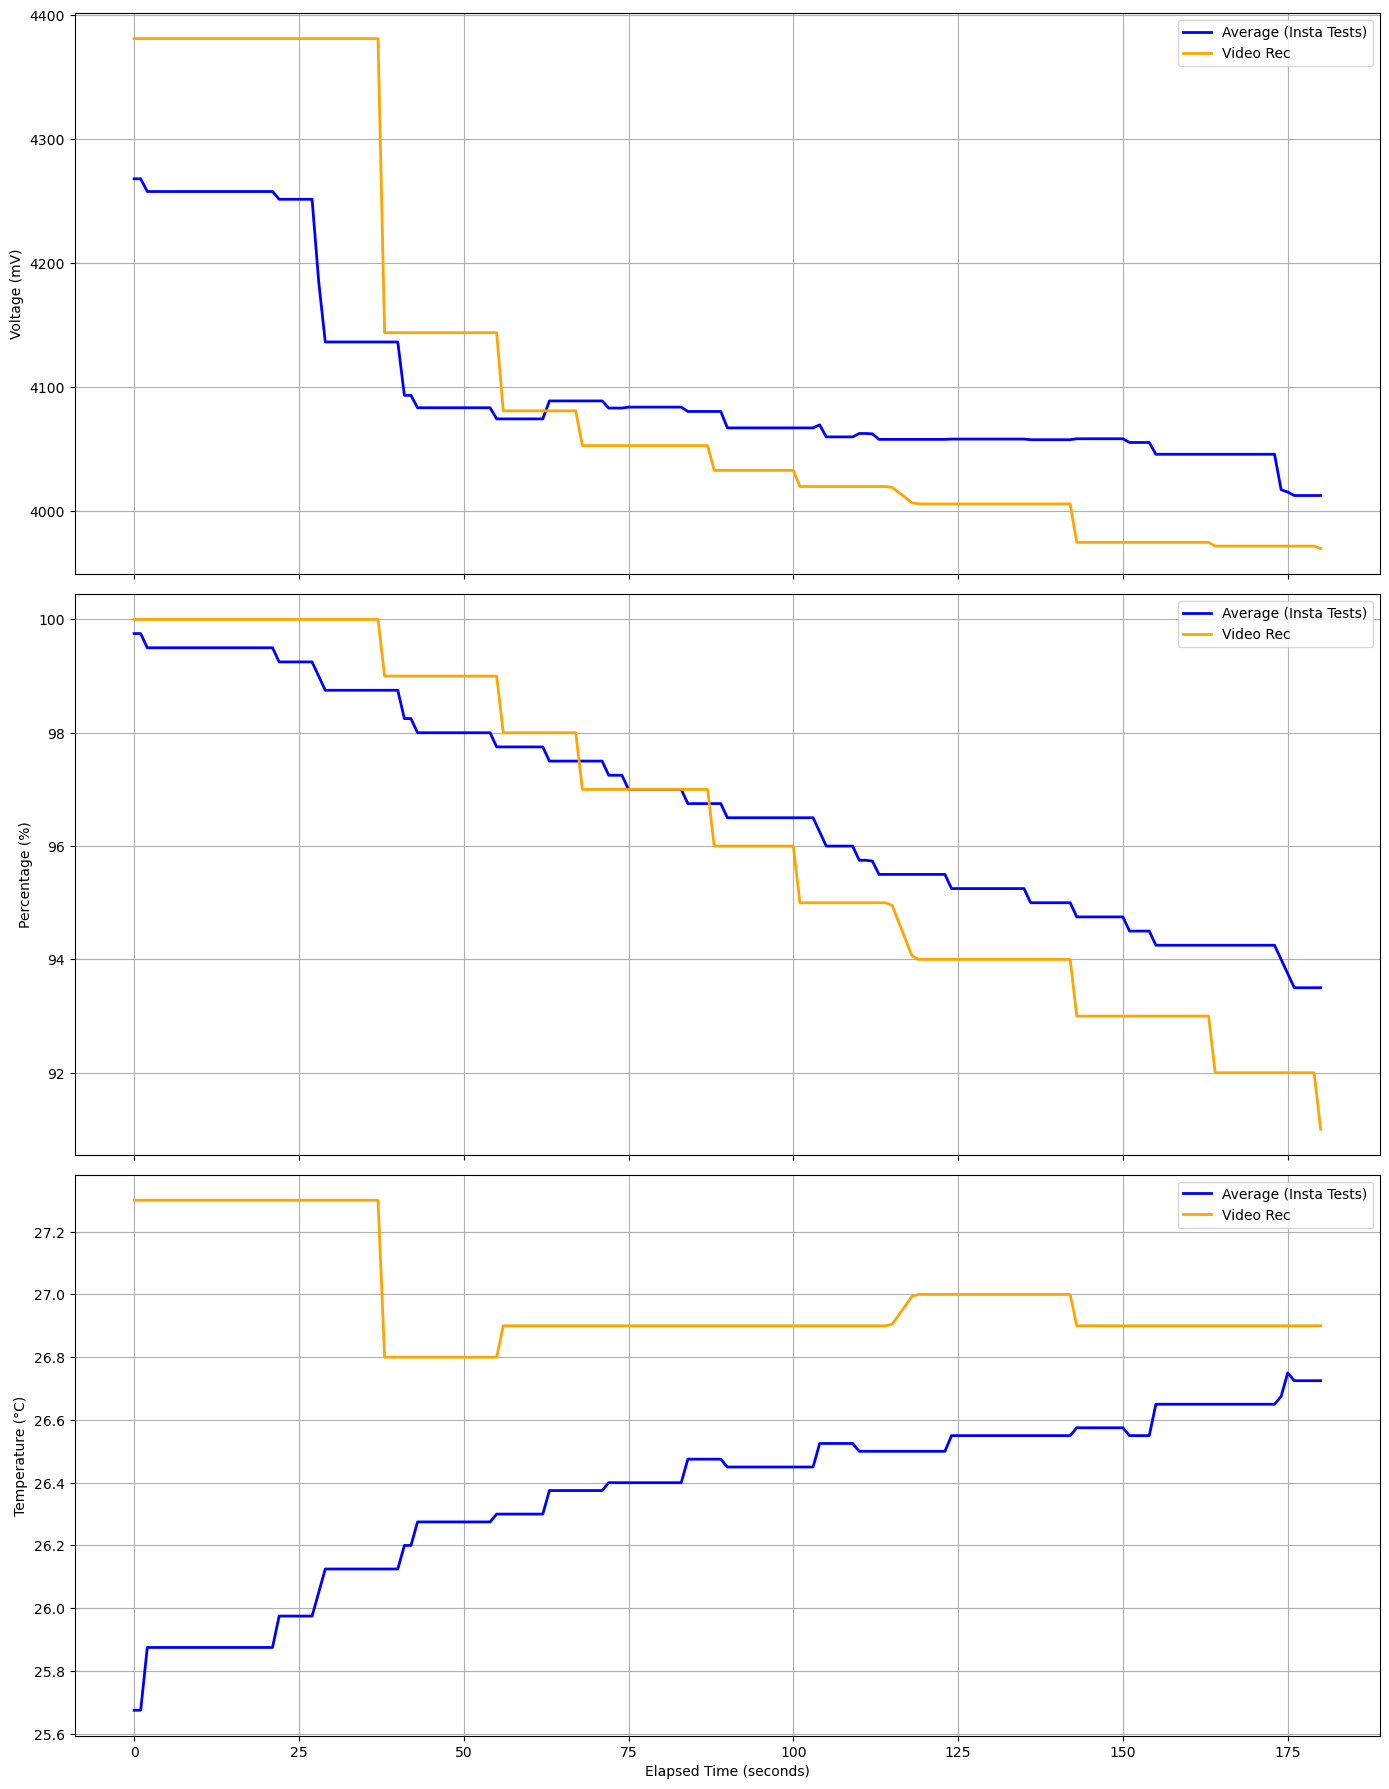

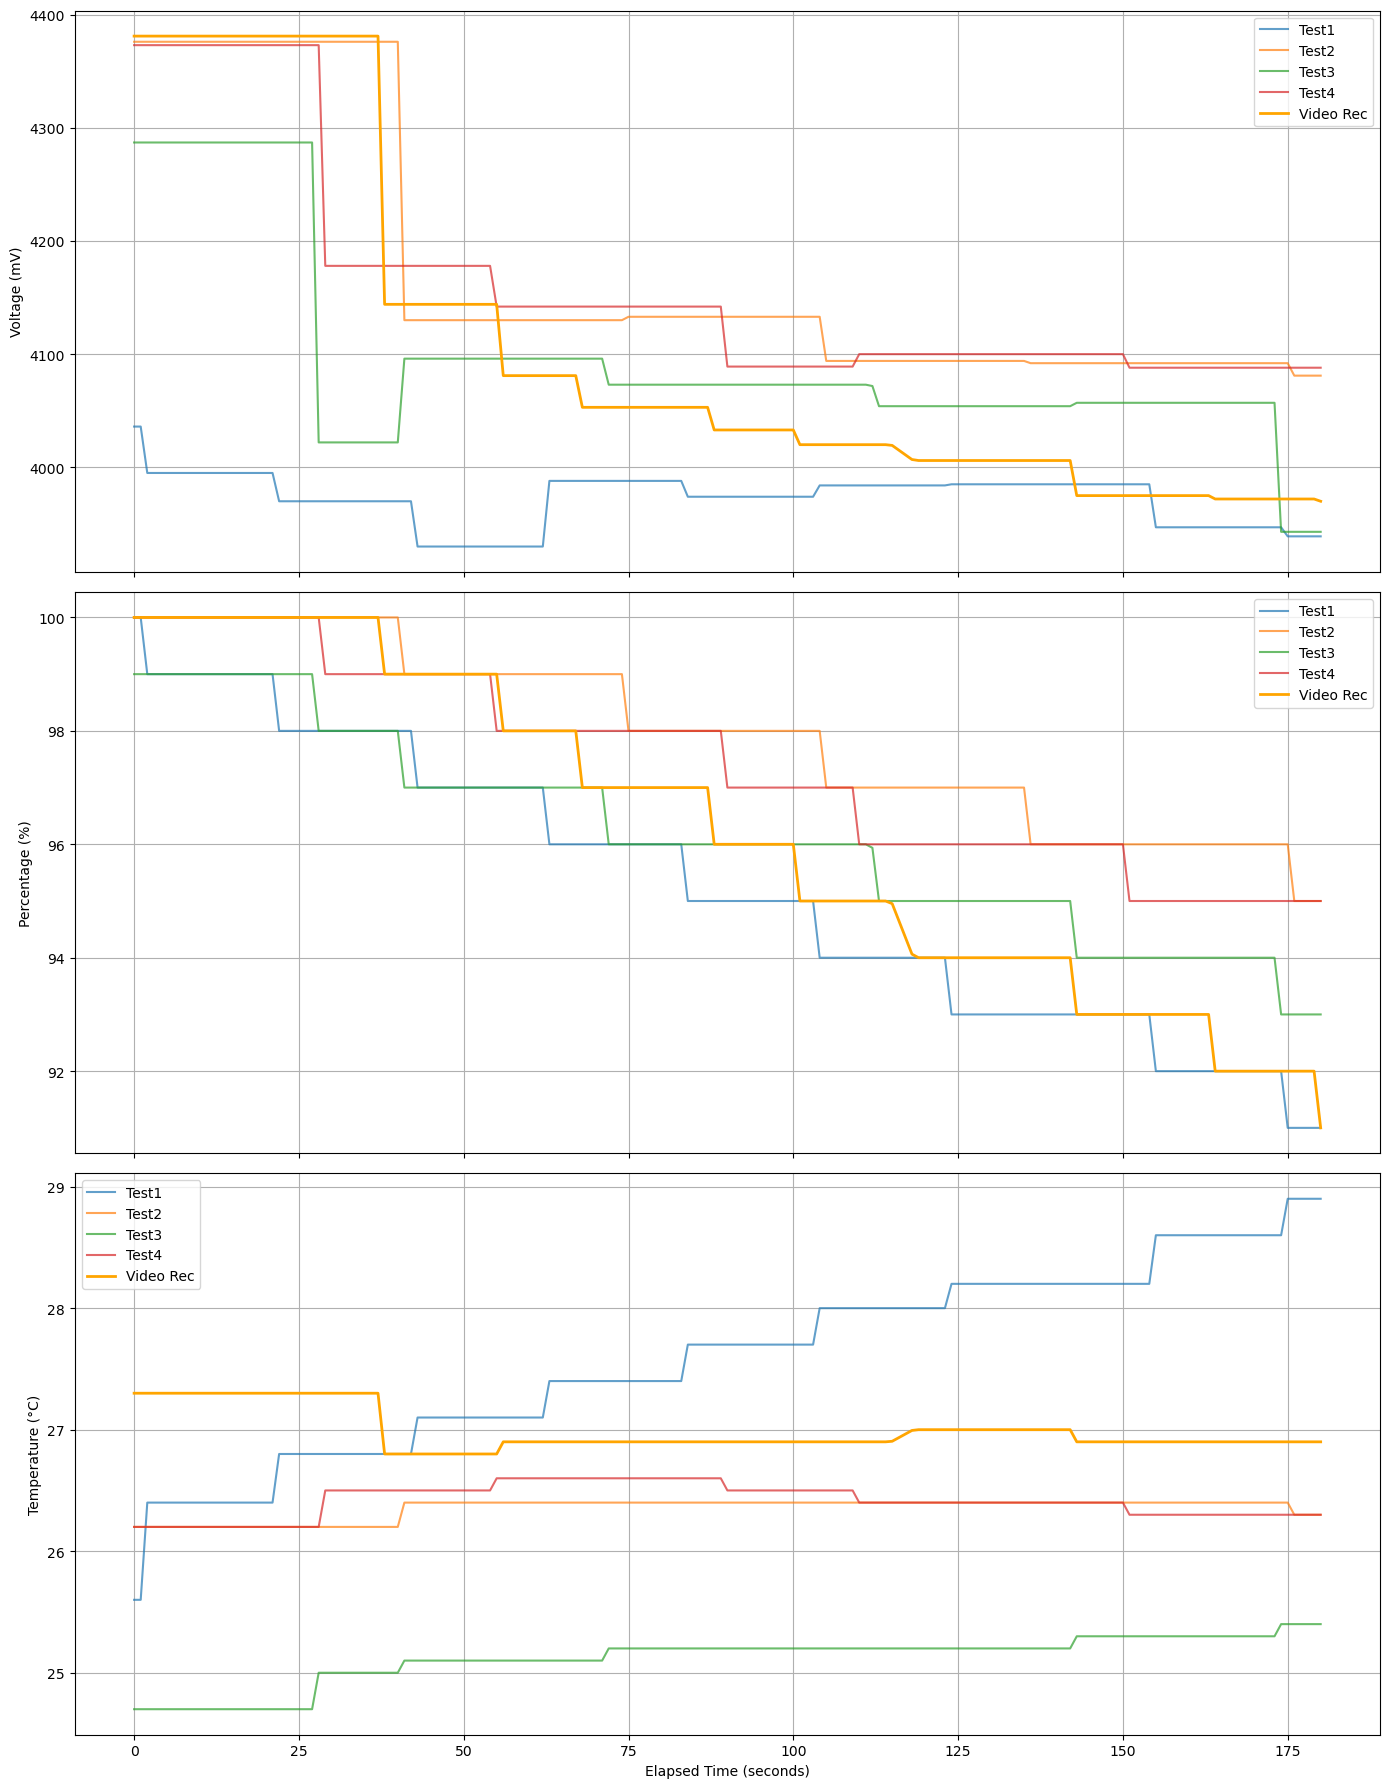

In [2]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from datetime import datetime

# Set up plotting style
plt.style.use('default')
plt.rcParams['figure.figsize'] = (14, 10)

# Load the previous CSV files for averaging
files = {
    'Test1': 'Test1_logcat_BT_RB_insta.csv',
    'Test2': 'Test2_logcat_BT_RB_insta.csv',
    'Test3': 'Test3_logcat_BT_RB_insta.csv',
    'Test4': 'Test4_logcat_BT_RB_insta.csv'
}

files = {
    'Test1': 'Test1_logcat_BT_RB_insta.csv',
    'Test2': 'Test2_logcat_BT_RB_insta.csv',
    'Test3': 'Test3_logcat_BT_RB_insta.csv',
    'Test4': 'Test4_logcat_BT_RB_insta.csv'
}

dataframes = {}
for name, file in files.items():
    df = pd.read_csv(file)
    # Parse Timestamp to datetime
    df['Timestamp'] = pd.to_datetime(df['Timestamp'])
    # Ensure Elapsed Time is float
    df['Elapsed Time'] = df['Elapsed Time'].astype(float)
    # Temperature might be in tenths, but from data it seems already in C (e.g., 25.6)
    if 'Temperature' in df.columns:
        df['Temperature'] = df['Temperature'].astype(float)
    dataframes[name] = df
    print(f"Loaded {name}: {len(df)} rows")

# Load the new Video Rec file
video_file = 'Test1_logcat_RB_Video_Rec.csv'
video_df = pd.read_csv(video_file)
video_df['Timestamp'] = pd.to_datetime(video_df['Timestamp'])
video_df['Elapsed Time'] = video_df['Elapsed Time'].astype(float)
if 'Temperature' in video_df.columns:
    video_df['Temperature'] = video_df['Temperature'].astype(float)
print(f"Loaded Video Rec: {len(video_df)} rows")

# Find the common time range for the average (0 to min max elapsed time of the four tests)
max_times = [df['Elapsed Time'].max() for df in dataframes.values()]
common_max_time = min(max_times)
print(f"Common max elapsed time for average: {common_max_time:.2f} seconds")

# For plotting average vs video, use min of average max and video max
video_max_time = video_df['Elapsed Time'].max()
plot_max_time = min(common_max_time, video_max_time)
print(f"Plot max elapsed time (min of avg and video): {plot_max_time:.2f} seconds")

# Create a common time grid (1-second intervals)
time_grid = np.arange(0, plot_max_time + 1, 1)

# Interpolate each dataset to the common time grid for the four tests
interpolated_dfs = {}
for name, df in dataframes.items():
    # Sort by elapsed time just in case
    df_sorted = df.sort_values('Elapsed Time').reset_index(drop=True)
    
    # Interpolate Voltage
    interp_voltage = interp1d(df_sorted['Elapsed Time'], df_sorted['Voltage'], 
                              kind='linear', bounds_error=False, fill_value='extrapolate')
    voltages = interp_voltage(time_grid)
    
    # Interpolate Percentage
    interp_perc = interp1d(df_sorted['Elapsed Time'], df_sorted['Percentage'], 
                           kind='linear', bounds_error=False, fill_value='extrapolate')
    percs = interp_perc(time_grid)
    
    # Interpolate Temperature if available
    if 'Temperature' in df.columns:
        interp_temp = interp1d(df_sorted['Elapsed Time'], df_sorted['Temperature'], 
                               kind='linear', bounds_error=False, fill_value='extrapolate')
        temps = interp_temp(time_grid)
        interp_df = pd.DataFrame({'Time': time_grid, 'Voltage': voltages, 'Percentage': percs, 'Temperature': temps})
    else:
        interp_df = pd.DataFrame({'Time': time_grid, 'Voltage': voltages, 'Percentage': percs})
    
    interpolated_dfs[name] = interp_df
    print(f"Interpolated {name}")

# Compute Averages for the four tests
avg_df = pd.DataFrame({'Time': time_grid})
for metric in ['Voltage', 'Percentage']:
    avg_df[metric] = np.mean([df[metric] for df in interpolated_dfs.values()], axis=0)

if all('Temperature' in df.columns for df in interpolated_dfs.values()):
    avg_df['Temperature'] = np.mean([df['Temperature'] for df in interpolated_dfs.values()], axis=0)

print("Average DataFrame shape:", avg_df.shape)
print(avg_df.head())

# Interpolate the Video Rec to the plot time grid
video_sorted = video_df.sort_values('Elapsed Time').reset_index(drop=True)

# Interpolate Voltage
interp_video_voltage = interp1d(video_sorted['Elapsed Time'], video_sorted['Voltage'], 
                                kind='linear', bounds_error=False, fill_value='extrapolate')
video_voltages = interp_video_voltage(time_grid)

# Interpolate Percentage
interp_video_perc = interp1d(video_sorted['Elapsed Time'], video_sorted['Percentage'], 
                             kind='linear', bounds_error=False, fill_value='extrapolate')
video_percs = interp_video_perc(time_grid)

# Interpolate Temperature if available
if 'Temperature' in video_df.columns:
    interp_video_temp = interp1d(video_sorted['Elapsed Time'], video_sorted['Temperature'], 
                                 kind='linear', bounds_error=False, fill_value='extrapolate')
    video_temps = interp_video_temp(time_grid)
    video_interp_df = pd.DataFrame({'Time': time_grid, 'Voltage': video_voltages, 'Percentage': video_percs, 'Temperature': video_temps})
else:
    video_interp_df = pd.DataFrame({'Time': time_grid, 'Voltage': video_voltages, 'Percentage': video_percs})

print("Video Rec interpolated")

# Plot the Averages vs Video Rec
fig, axes = plt.subplots(3, 1, figsize=(14, 18), sharex=True)

# Plot Voltage
axes[0].plot(avg_df['Time'], avg_df['Voltage'], linewidth=2, color='blue', label='Average (Insta Tests)')
axes[0].plot(video_interp_df['Time'], video_interp_df['Voltage'], linewidth=2, color='orange', label='Video Rec')
axes[0].set_ylabel('Voltage (mV)')
axes[0].legend()
axes[0].grid(True)

# Plot Percentage
axes[1].plot(avg_df['Time'], avg_df['Percentage'], linewidth=2, color='blue', label='Average (Insta Tests)')
axes[1].plot(video_interp_df['Time'], video_interp_df['Percentage'], linewidth=2, color='orange', label='Video Rec')
axes[1].set_ylabel('Percentage (%)')
axes[1].legend()
axes[1].grid(True)
# Plot Temperature
if 'Temperature' in avg_df.columns and 'Temperature' in video_interp_df.columns:
    axes[2].plot(avg_df['Time'], avg_df['Temperature'], linewidth=2, color='blue', label='Average (Insta Tests)')
    axes[2].plot(video_interp_df['Time'], video_interp_df['Temperature'], linewidth=2, color='orange', label='Video Rec')
    axes[2].set_ylabel('Temperature (°C)')
else:
    axes[2].text(0.5, 0.5, 'No Temperature Data', ha='center', va='center', transform=axes[2].transAxes)

axes[2].legend()
axes[2].grid(True)
plt.xlabel('Elapsed Time (seconds)')
plt.tight_layout()
plt.show()

# Optional - Plot Individual Insta Tests + Video Rec for Comparison
fig, axes = plt.subplots(3, 1, figsize=(14, 18), sharex=True)

for name, df in interpolated_dfs.items():
    axes[0].plot(df['Time'], df['Voltage'], label=name, alpha=0.7)
    axes[1].plot(df['Time'], df['Percentage'], label=name, alpha=0.7)
    if 'Temperature' in df.columns:
        axes[2].plot(df['Time'], df['Temperature'], label=name, alpha=0.7)

# Add Video Rec to comparison
axes[0].plot(video_interp_df['Time'], video_interp_df['Voltage'], label='Video Rec', linewidth=2, color='orange')
axes[1].plot(video_interp_df['Time'], video_interp_df['Percentage'], label='Video Rec', linewidth=2, color='orange')
if 'Temperature' in video_interp_df.columns:
    axes[2].plot(video_interp_df['Time'], video_interp_df['Temperature'], label='Video Rec', linewidth=2, color='orange')

axes[0].set_ylabel('Voltage (mV)')
axes[0].legend()
axes[0].grid(True)

axes[1].set_ylabel('Percentage (%)')
axes[1].legend()
axes[1].grid(True)

if 'Temperature' in interpolated_dfs[list(interpolated_dfs.keys())[0]].columns:
    axes[2].set_ylabel('Temperature (°C)')
    axes[2].legend()
axes[2].grid(True)

plt.xlabel('Elapsed Time (seconds)')
plt.tight_layout()
plt.show()

# **Bar Plot for Voltage**

Loaded BT Test3: 319 rows
Loaded BT Test4: 436 rows
Loaded Video Rec Vid1: 155 rows
Loaded Video Rec Vid2: 222 rows
Loaded WD WD1: 190 rows
Common max elapsed time for BT average: 234.33 seconds
Common max elapsed time for Video Rec average: 179.79 seconds
Common max elapsed time for WD average: 136.39 seconds
Plot max elapsed time (min of all): 136.39 seconds
Interpolated BT Test3
Interpolated BT Test4
BT Average DataFrame shape: (138, 4)
   Time  Voltage  Percentage  Temperature
0   0.0   4330.0        99.5        25.45
1   1.0   4330.0        99.5        25.45
2   2.0   4330.0        99.5        25.45
3   3.0   4330.0        99.5        25.45
4   4.0   4330.0        99.5        25.45
Interpolated Video Rec Vid1
Interpolated Video Rec Vid2
Video Rec Average DataFrame shape: (138, 4)
   Time  Voltage  Percentage  Temperature
0   0.0   4378.5       100.0        26.95
1   1.0   4378.5       100.0        26.95
2   2.0   4378.5       100.0        26.95
3   3.0   4378.5       100.0        

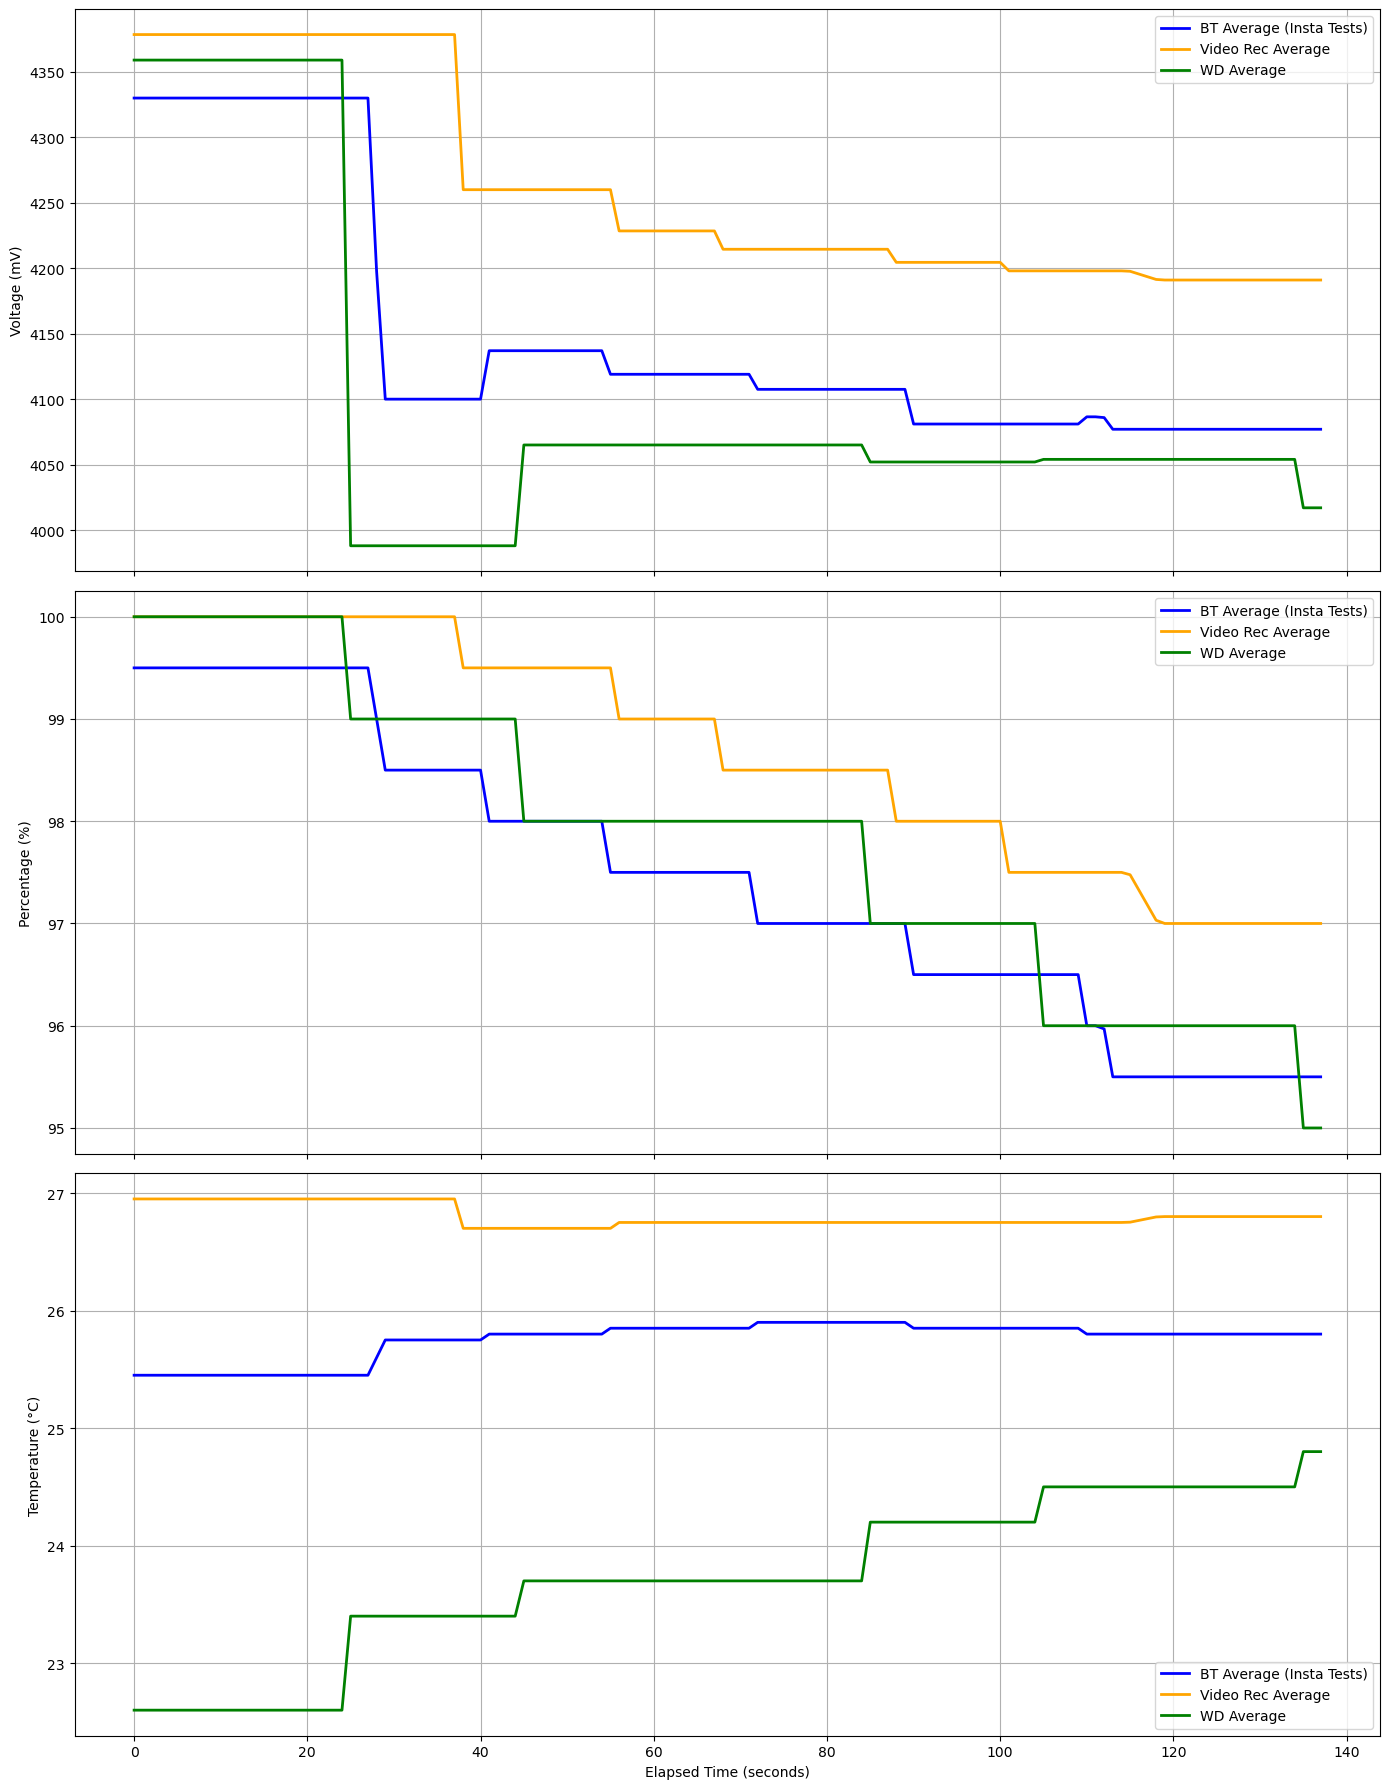

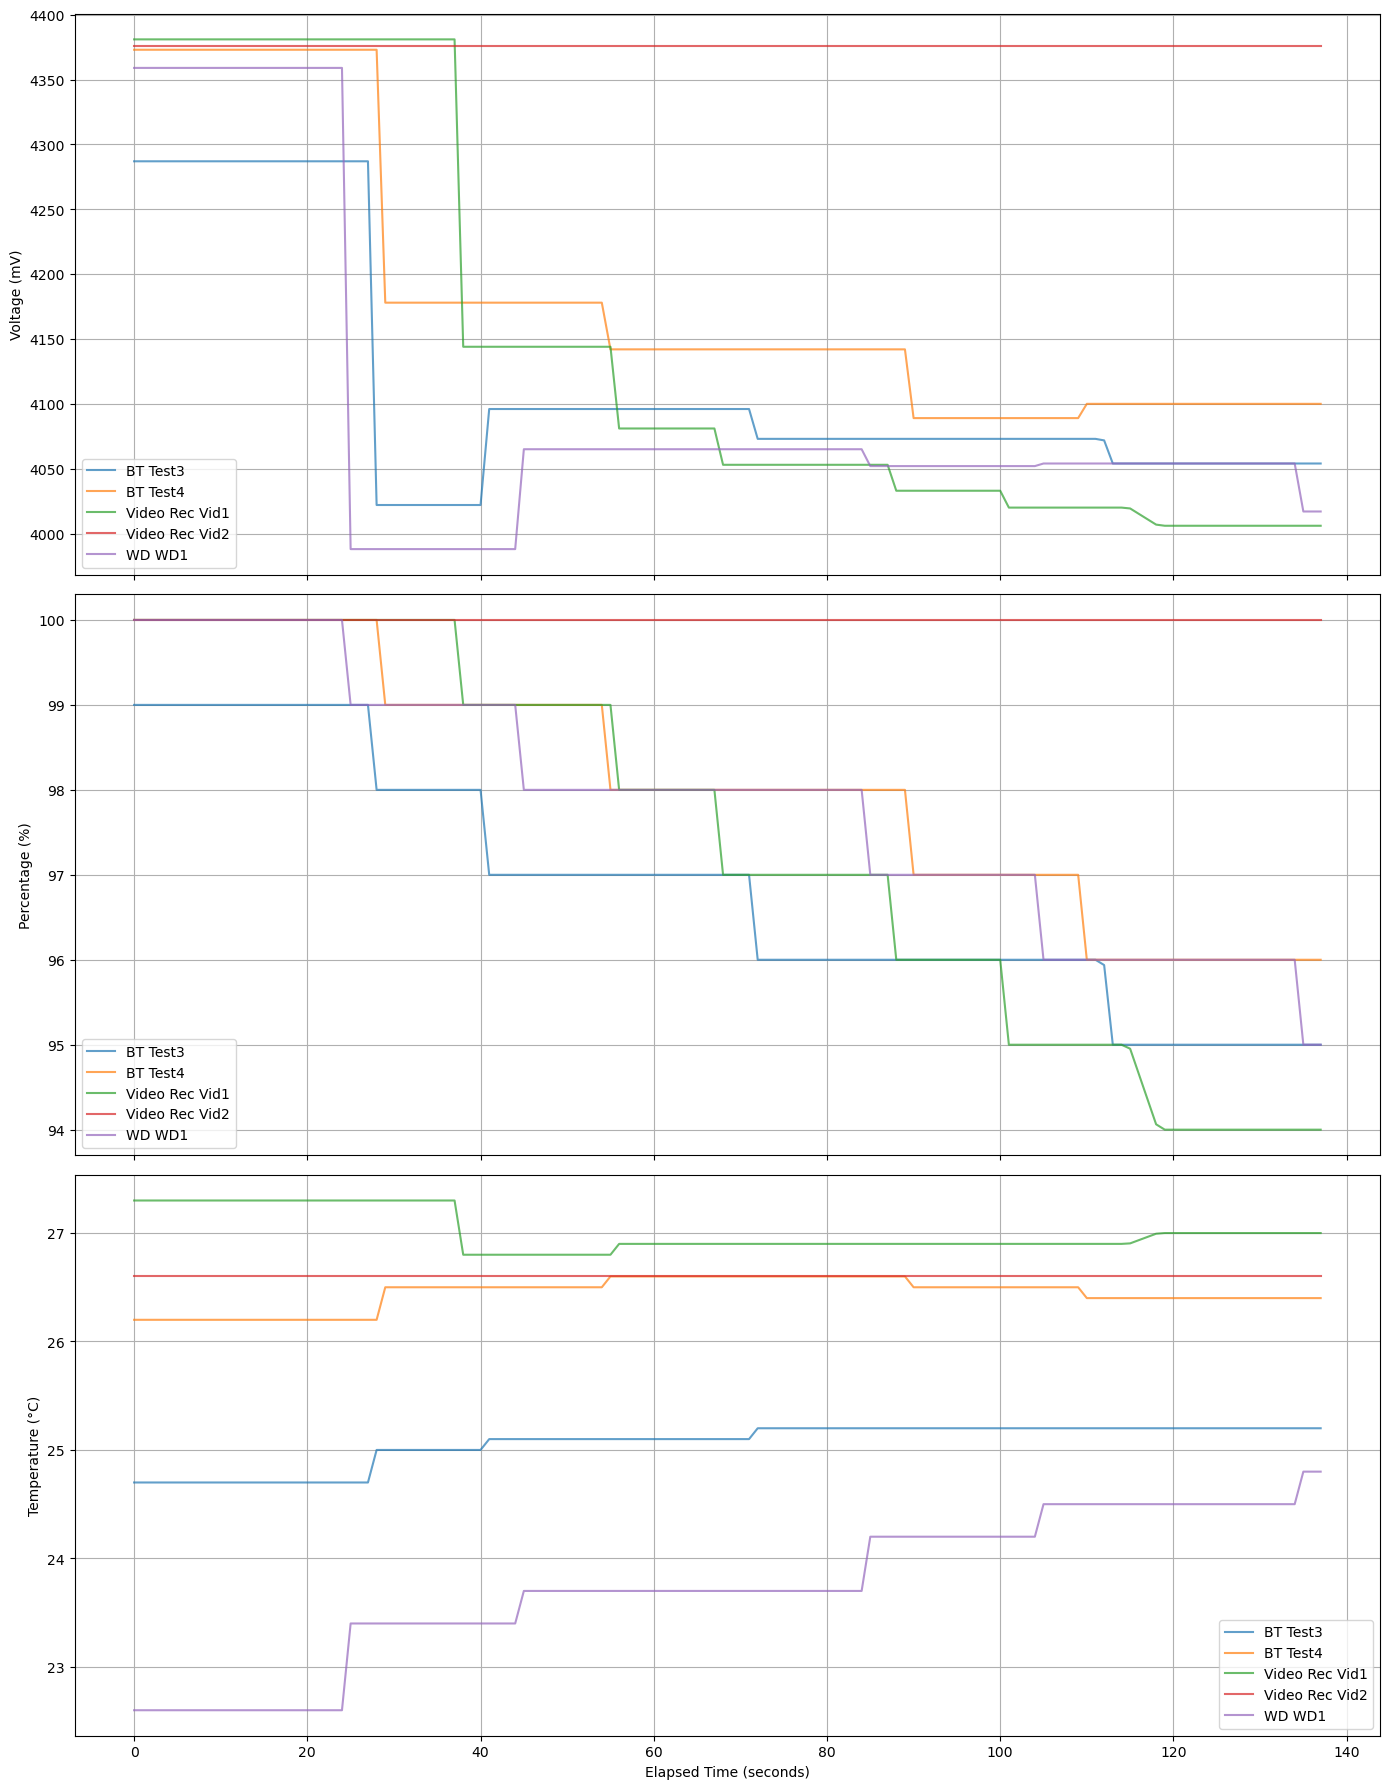

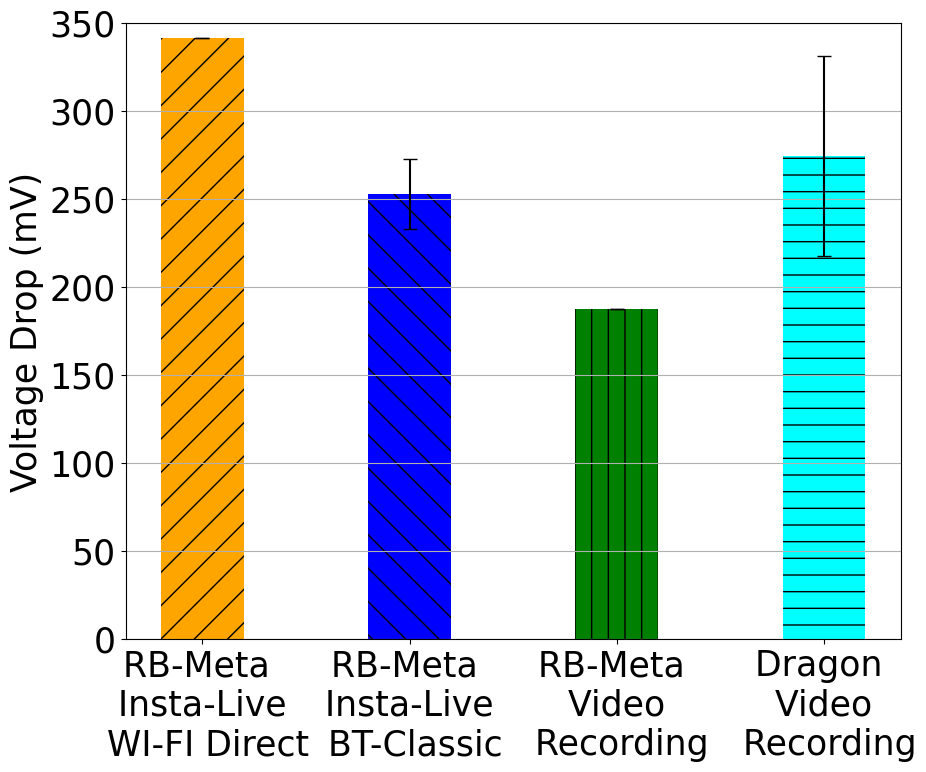

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from datetime import datetime

# Set up plotting style
plt.style.use('default')
plt.rcParams['figure.figsize'] = (14, 10)

# Load the previous CSV files for BT (Insta) averaging
bt_files = {
    # 'Test1': 'Test1_logcat_BT_RB_insta.csv',
    # 'Test2': 'Test2_logcat_BT_RB_insta.csv',
    'Test3': 'Test3_logcat_BT_RB_insta.csv',
    'Test4': 'Test4_logcat_BT_RB_insta.csv'
}

bt_dataframes = {}
for name, file in bt_files.items():
    df = pd.read_csv(file)
    # Parse Timestamp to datetime
    df['Timestamp'] = pd.to_datetime(df['Timestamp'])
    # Ensure Elapsed Time is float
    df['Elapsed Time'] = df['Elapsed Time'].astype(float)
    # Temperature might be in tenths, but from data it seems already in C (e.g., 25.6)
    if 'Temperature' in df.columns:
        df['Temperature'] = df['Temperature'].astype(float)
    bt_dataframes[name] = df
    print(f"Loaded BT {name}: {len(df)} rows")

# Load multiple Video Rec files for averaging
video_files = [
    'Test1_logcat_RB_Video_Rec.csv',
    'Test2_logcat_RB_Video_Rec.csv'
    #'Test3_logcat_RB_Video_Rec.csv',
    # 'Test4_logcat_RB_Video_Rec.csv'
]
video_dataframes = {}
for i, file in enumerate(video_files):
    name = f'Vid{i+1}'
    df = pd.read_csv(file)
    df['Timestamp'] = pd.to_datetime(df['Timestamp'])
    df['Elapsed Time'] = df['Elapsed Time'].astype(float)
    if 'Temperature' in df.columns:
        df['Temperature'] = df['Temperature'].astype(float)
    video_dataframes[name] = df
    print(f"Loaded Video Rec {name}: {len(df)} rows")

# Load multiple WD files for averaging
wd_files = [
    # 'Test2_logcat_WD_RB_insta_live.csv',
    'Test3_logcat_WD_RB_insta_live.csv'
    # 'Test3_logcat_RB_WD.csv',
    # 'Test4_logcat_RB_WD.csv'
]
wd_dataframes = {}
for i, file in enumerate(wd_files):
    name = f'WD{i+1}'
    df = pd.read_csv(file)
    df['Timestamp'] = pd.to_datetime(df['Timestamp'])
    df['Elapsed Time'] = df['Elapsed Time'].astype(float)
    if 'Temperature' in df.columns:
        df['Temperature'] = df['Temperature'].astype(float)
    wd_dataframes[name] = df
    print(f"Loaded WD {name}: {len(df)} rows")

# Find the common time range for BT average
bt_max_times = [df['Elapsed Time'].max() for df in bt_dataframes.values()]
common_bt_max_time = min(bt_max_times)
print(f"Common max elapsed time for BT average: {common_bt_max_time:.2f} seconds")

# Find the common time range for Video Rec average
video_max_times = [df['Elapsed Time'].max() for df in video_dataframes.values()]
common_video_max_time = min(video_max_times)
print(f"Common max elapsed time for Video Rec average: {common_video_max_time:.2f} seconds")

# Find the common time range for WD average
wd_max_times = [df['Elapsed Time'].max() for df in wd_dataframes.values()]
common_wd_max_time = min(wd_max_times)
print(f"Common max elapsed time for WD average: {common_wd_max_time:.2f} seconds")

# For plotting, use min of all max times
plot_max_time = min(common_bt_max_time, common_video_max_time, common_wd_max_time)
print(f"Plot max elapsed time (min of all): {plot_max_time:.2f} seconds")

# Create a common time grid (1-second intervals)
time_grid = np.arange(0, plot_max_time + 1, 1)

# Interpolate each BT dataset to the common time grid
interpolated_bt_dfs = {}
for name, df in bt_dataframes.items():
    # Sort by elapsed time just in case
    df_sorted = df.sort_values('Elapsed Time').reset_index(drop=True)
    
    # Interpolate Voltage
    interp_voltage = interp1d(df_sorted['Elapsed Time'], df_sorted['Voltage'], 
                              kind='linear', bounds_error=False, fill_value='extrapolate')
    voltages = interp_voltage(time_grid)
    
    # Interpolate Percentage
    interp_perc = interp1d(df_sorted['Elapsed Time'], df_sorted['Percentage'], 
                           kind='linear', bounds_error=False, fill_value='extrapolate')
    percs = interp_perc(time_grid)
    
    # Interpolate Temperature if available
    if 'Temperature' in df.columns:
        interp_temp = interp1d(df_sorted['Elapsed Time'], df_sorted['Temperature'], 
                               kind='linear', bounds_error=False, fill_value='extrapolate')
        temps = interp_temp(time_grid)
        interp_df = pd.DataFrame({'Time': time_grid, 'Voltage': voltages, 'Percentage': percs, 'Temperature': temps})
    else:
        interp_df = pd.DataFrame({'Time': time_grid, 'Voltage': voltages, 'Percentage': percs})
    
    interpolated_bt_dfs[name] = interp_df
    print(f"Interpolated BT {name}")

# Compute Averages for BT tests
avg_bt_df = pd.DataFrame({'Time': time_grid})
for metric in ['Voltage', 'Percentage']:
    avg_bt_df[metric] = np.mean([df[metric] for df in interpolated_bt_dfs.values()], axis=0)

if all('Temperature' in df.columns for df in interpolated_bt_dfs.values()):
    avg_bt_df['Temperature'] = np.mean([df['Temperature'] for df in interpolated_bt_dfs.values()], axis=0)

print("BT Average DataFrame shape:", avg_bt_df.shape)
print(avg_bt_df.head())

# Interpolate each Video Rec dataset
interpolated_video_dfs = {}
for name, df in video_dataframes.items():
    df_sorted = df.sort_values('Elapsed Time').reset_index(drop=True)
    
    interp_voltage = interp1d(df_sorted['Elapsed Time'], df_sorted['Voltage'], 
                              kind='linear', bounds_error=False, fill_value='extrapolate')
    voltages = interp_voltage(time_grid)
    
    interp_perc = interp1d(df_sorted['Elapsed Time'], df_sorted['Percentage'], 
                           kind='linear', bounds_error=False, fill_value='extrapolate')
    percs = interp_perc(time_grid)
    
    if 'Temperature' in df.columns:
        interp_temp = interp1d(df_sorted['Elapsed Time'], df_sorted['Temperature'], 
                               kind='linear', bounds_error=False, fill_value='extrapolate')
        temps = interp_temp(time_grid)
        interp_df = pd.DataFrame({'Time': time_grid, 'Voltage': voltages, 'Percentage': percs, 'Temperature': temps})
    else:
        interp_df = pd.DataFrame({'Time': time_grid, 'Voltage': voltages, 'Percentage': percs})
    
    interpolated_video_dfs[name] = interp_df
    print(f"Interpolated Video Rec {name}")

# Compute Averages for Video Rec tests
avg_video_df = pd.DataFrame({'Time': time_grid})
for metric in ['Voltage', 'Percentage']:
    avg_video_df[metric] = np.mean([df[metric] for df in interpolated_video_dfs.values()], axis=0)

if all('Temperature' in df.columns for df in interpolated_video_dfs.values()):
    avg_video_df['Temperature'] = np.mean([df['Temperature'] for df in interpolated_video_dfs.values()], axis=0)

print("Video Rec Average DataFrame shape:", avg_video_df.shape)
print(avg_video_df.head())

# Interpolate each WD dataset
interpolated_wd_dfs = {}
for name, df in wd_dataframes.items():
    df_sorted = df.sort_values('Elapsed Time').reset_index(drop=True)
    
    interp_voltage = interp1d(df_sorted['Elapsed Time'], df_sorted['Voltage'], 
                              kind='linear', bounds_error=False, fill_value='extrapolate')
    voltages = interp_voltage(time_grid)
    
    interp_perc = interp1d(df_sorted['Elapsed Time'], df_sorted['Percentage'], 
                           kind='linear', bounds_error=False, fill_value='extrapolate')
    percs = interp_perc(time_grid)
    
    if 'Temperature' in df.columns:
        interp_temp = interp1d(df_sorted['Elapsed Time'], df_sorted['Temperature'], 
                               kind='linear', bounds_error=False, fill_value='extrapolate')
        temps = interp_temp(time_grid)
        interp_df = pd.DataFrame({'Time': time_grid, 'Voltage': voltages, 'Percentage': percs, 'Temperature': temps})
    else:
        interp_df = pd.DataFrame({'Time': time_grid, 'Voltage': voltages, 'Percentage': percs})
    
    interpolated_wd_dfs[name] = interp_df
    print(f"Interpolated WD {name}")

# Load Cyan data
avg_cyan_df = pd.read_csv('Cyan Voltage Tests.csv')
avg_cyan_values = avg_cyan_df['Voltage (V)'].values  # Assuming these are voltage drops; if in V, multiply by 1000 for mV

# Compute Averages for WD tests
avg_wd_df = pd.DataFrame({'Time': time_grid})
for metric in ['Voltage', 'Percentage']:
    avg_wd_df[metric] = np.mean([df[metric] for df in interpolated_wd_dfs.values()], axis=0)

if all('Temperature' in df.columns for df in interpolated_wd_dfs.values()):
    avg_wd_df['Temperature'] = np.mean([df['Temperature'] for df in interpolated_wd_dfs.values()], axis=0)

print("WD Average DataFrame shape:", avg_wd_df.shape)
print(avg_wd_df.head())

# Plot the Averages: BT vs Video Rec vs WD
fig, axes = plt.subplots(3, 1, figsize=(14, 18), sharex=True)

# Plot Voltage
axes[0].plot(avg_bt_df['Time'], avg_bt_df['Voltage'], linewidth=2, color='blue', label='BT Average (Insta Tests)')
axes[0].plot(avg_video_df['Time'], avg_video_df['Voltage'], linewidth=2, color='orange', label='Video Rec Average')
axes[0].plot(avg_wd_df['Time'], avg_wd_df['Voltage'], linewidth=2, color='green', label='WD Average')
axes[0].set_ylabel('Voltage (mV)')
axes[0].legend()
axes[0].grid(True)

# Plot Percentage
axes[1].plot(avg_bt_df['Time'], avg_bt_df['Percentage'], linewidth=2, color='blue', label='BT Average (Insta Tests)')
axes[1].plot(avg_video_df['Time'], avg_video_df['Percentage'], linewidth=2, color='orange', label='Video Rec Average')
axes[1].plot(avg_wd_df['Time'], avg_wd_df['Percentage'], linewidth=2, color='green', label='WD Average')
axes[1].set_ylabel('Percentage (%)')
axes[1].legend()
axes[1].grid(True)

# Plot Temperature
if 'Temperature' in avg_bt_df.columns and 'Temperature' in avg_video_df.columns and 'Temperature' in avg_wd_df.columns:
    axes[2].plot(avg_bt_df['Time'], avg_bt_df['Temperature'], linewidth=2, color='blue', label='BT Average (Insta Tests)')
    axes[2].plot(avg_video_df['Time'], avg_video_df['Temperature'], linewidth=2, color='orange', label='Video Rec Average')
    axes[2].plot(avg_wd_df['Time'], avg_wd_df['Temperature'], linewidth=2, color='green', label='WD Average')
    axes[2].set_ylabel('Temperature (°C)')
else:
    axes[2].text(0.5, 0.5, 'No Temperature Data', ha='center', va='center', transform=axes[2].transAxes)

axes[2].legend()
axes[2].grid(True)
plt.xlabel('Elapsed Time (seconds)')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(3, 1, figsize=(14, 18), sharex=True)

for name, df in interpolated_bt_dfs.items():
    axes[0].plot(df['Time'], df['Voltage'], label=f'BT {name}', alpha=0.7)
    axes[1].plot(df['Time'], df['Percentage'], label=f'BT {name}', alpha=0.7)
    if 'Temperature' in df.columns:
        axes[2].plot(df['Time'], df['Temperature'], label=f'BT {name}', alpha=0.7)

for name, df in interpolated_video_dfs.items():
    axes[0].plot(df['Time'], df['Voltage'], label=f'Video Rec {name}', alpha=0.7)
    axes[1].plot(df['Time'], df['Percentage'], label=f'Video Rec {name}', alpha=0.7)
    if 'Temperature' in df.columns:
        axes[2].plot(df['Time'], df['Temperature'], label=f'Video Rec {name}', alpha=0.7)

for name, df in interpolated_wd_dfs.items():
    axes[0].plot(df['Time'], df['Voltage'], label=f'WD {name}', alpha=0.7)
    axes[1].plot(df['Time'], df['Percentage'], label=f'WD {name}', alpha=0.7)
    if 'Temperature' in df.columns:
        axes[2].plot(df['Time'], df['Temperature'], label=f'WD {name}', alpha=0.7)

axes[0].set_ylabel('Voltage (mV)')
axes[0].legend()
axes[0].grid(True)

axes[1].set_ylabel('Percentage (%)')
axes[1].legend()
axes[1].grid(True)

if 'Temperature' in interpolated_bt_dfs[list(interpolated_bt_dfs.keys())[0]].columns:
    axes[2].set_ylabel('Temperature (°C)')
    axes[2].legend()
axes[2].grid(True)

plt.xlabel('Elapsed Time (seconds)')
plt.tight_layout()
plt.show()

# Voltage Drop Bar Plot (0s to 150s)
# First, determine the time index (fallback to max if <150s available)
time_point = min(150, plot_max_time)
time_index = int(time_point)  # Since time_grid step is 1

if time_index > 0:
    # Compute individual voltage drops for each group
    bt_drops = [df.iloc[0]['Voltage'] - df.iloc[time_index]['Voltage'] for df in interpolated_bt_dfs.values()]
    drop_bt = np.mean(bt_drops)
    std_bt = np.std(bt_drops) if len(bt_drops) > 1 else 0
    
    video_drops = [df.iloc[0]['Voltage'] - df.iloc[time_index]['Voltage'] for df in interpolated_video_dfs.values()]
    drop_video = np.mean(video_drops)
    std_video = np.std(video_drops) if len(video_drops) > 1 else 0
    
    wd_drops = [df.iloc[0]['Voltage'] - df.iloc[time_index]['Voltage'] for df in interpolated_wd_dfs.values()]
    drop_wd = np.mean(wd_drops)
    std_wd = np.std(wd_drops) if len(wd_drops) > 1 else 0
    
    cyan_drops = avg_cyan_values  # Assuming these are already drops in mV
    avg_cyan_mean = np.mean(cyan_drops)
    std_cyan = np.std(cyan_drops) if len(cyan_drops) > 1 else 0
else:
    print("Warning: Data does not extend beyond 0 seconds.")
    drop_bt = drop_video = drop_wd = avg_cyan_mean = 0
    std_bt = std_video = std_wd = std_cyan = 0

categories = ['RB-Meta \n Insta-Live \n WI-FI Direct', 'RB-Meta \n Insta-Live \n BT-Classic', 'RB-Meta \n Video \n Recording', 'Dragon \n Video \n Recording']
drops = [drop_wd, drop_bt, drop_video, avg_cyan_mean]
stds = [std_wd, std_bt, std_wd, std_cyan]

plt.figure(figsize=(10, 8))
bars = plt.bar(categories, drops, yerr=stds, capsize=5, color=['orange', 'blue', 'green', 'cyan'], width=0.4)
# Add different hatch patterns to each bar for visual distinction
hatches = ['/', '\\', '|', '-']
for bar, hatch in zip(bars, hatches):
    bar.set_hatch(hatch)

plt.ylabel('Voltage Drop (mV)', fontsize=25)
plt.xticks(fontsize=25)
plt.yticks(fontsize=25)
plt.grid(True, axis='y')
plt.ylim(0, 350)
plt.savefig("../Plots/Volt_Battery_Bar_insta_RB.png")

plt.show()

# **Full Period Insta-Live**

Loaded Test1_WD: 7346 rows, max time: 1500.00s
Loaded Test4_BT: 2317 rows, max time: 2006.35s
Loaded Test_RB: 1085 rows, max time: 5790.13s
Plot max elapsed time: 5790.13 seconds


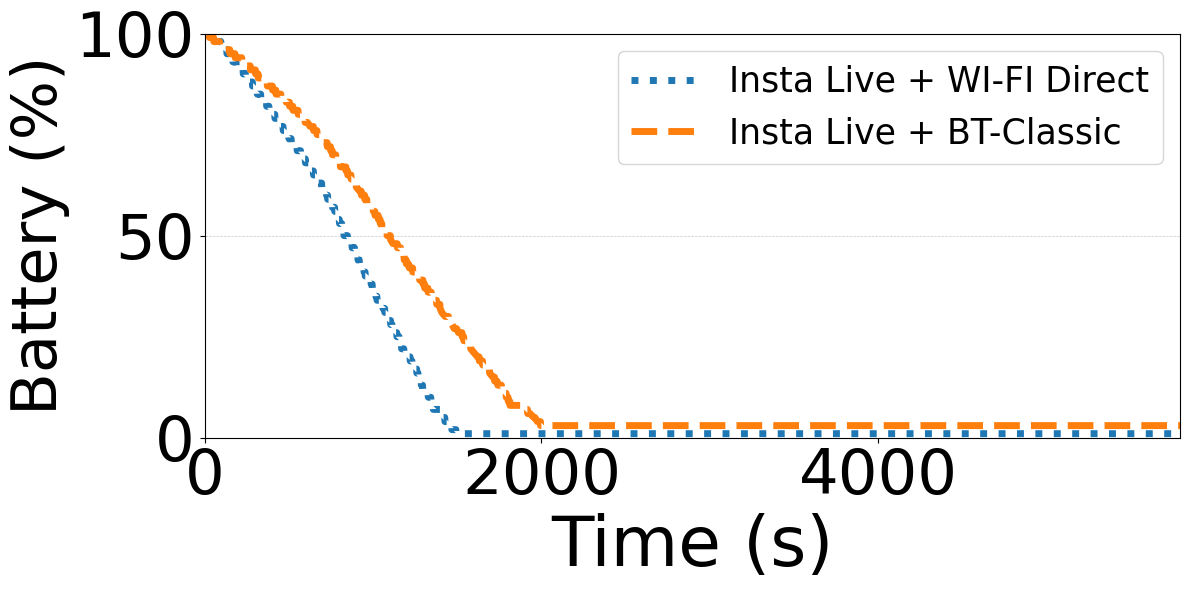

In [4]:
# Load the two CSV files
test1_wd = pd.read_csv('TestM1_logcat_WD_RB_insta_Full.csv')
test4_bt = pd.read_csv('Test4_logcat_BT_RB_insta_Full.csv')
test_RB = pd.read_csv('Battery_Data_RB_Display.csv')

# Parse Timestamps and ensure floats
test1_wd['Timestamp'] = pd.to_datetime(test1_wd['Timestamp'])
test4_bt['Timestamp'] = pd.to_datetime(test4_bt['Timestamp'])
test1_wd['Elapsed Time'] = test1_wd['Elapsed Time'].astype(float)
test4_bt['Elapsed Time'] = test4_bt['Elapsed Time'].astype(float)
test_RB['Elapsed Time'] = test_RB['Elapsed Time'].astype(float)


# Temperature to float
test1_wd['Temperature'] = test1_wd['Temperature'].astype(float)
test4_bt['Temperature'] = test4_bt['Temperature'].astype(float)
test_RB['Temperature'] = test_RB['Temperature'].astype(float)

print(f"Loaded Test1_WD: {len(test1_wd)} rows, max time: {test1_wd['Elapsed Time'].max():.2f}s")
print(f"Loaded Test4_BT: {len(test4_bt)} rows, max time: {test4_bt['Elapsed Time'].max():.2f}s")
print(f"Loaded Test_RB: {len(test_RB)} rows, max time: {test_RB['Elapsed Time'].max():.2f}s")

# Common time range - use max to let BT continue to the end
max_times = [test1_wd['Elapsed Time'].max(), test4_bt['Elapsed Time'].max(), test_RB['Elapsed Time'].max()]
plot_max_time = max(max_times)
time_grid = np.arange(0, plot_max_time + 1, 1)
print(f"Plot max elapsed time: {plot_max_time:.2f} seconds")

# Interpolate Test1_WD
test1_sorted = test1_wd.sort_values('Elapsed Time').reset_index(drop=True)
interp_v1 = interp1d(test1_sorted['Elapsed Time'], test1_sorted['Voltage'], kind='linear', bounds_error=False, fill_value='extrapolate')
interp_p1 = interp1d(test1_sorted['Elapsed Time'], test1_sorted['Percentage'], kind='linear', bounds_error=False, fill_value='extrapolate')
interp_t1 = interp1d(test1_sorted['Elapsed Time'], test1_sorted['Temperature'], kind='linear', bounds_error=False, fill_value='extrapolate')
wd_interp = pd.DataFrame({
    'Time': time_grid,
    'Voltage': interp_v1(time_grid),
    'Percentage': interp_p1(time_grid),
    'Temperature': interp_t1(time_grid)
})

# Interpolate Test4_BT
test4_sorted = test4_bt.sort_values('Elapsed Time').reset_index(drop=True)
interp_v4 = interp1d(test4_sorted['Elapsed Time'], test4_sorted['Voltage'], kind='linear', bounds_error=False, fill_value='extrapolate')
interp_p4 = interp1d(test4_sorted['Elapsed Time'], test4_sorted['Percentage'], kind='linear', bounds_error=False, fill_value='extrapolate')
interp_t4 = interp1d(test4_sorted['Elapsed Time'], test4_sorted['Temperature'], kind='linear', bounds_error=False, fill_value='extrapolate')
bt_interp = pd.DataFrame({
    'Time': time_grid,
    'Voltage': interp_v4(time_grid),
    'Percentage': interp_p4(time_grid),
    'Temperature': interp_t4(time_grid)
})

# Interpolate Test_RB
test_RB_sorted = test_RB.sort_values('Elapsed Time').reset_index(drop=True)
interp_v_rb = interp1d(test_RB_sorted['Elapsed Time'], test_RB_sorted['Voltage'], kind='linear', bounds_error=False, fill_value='extrapolate')
interp_p_rb = interp1d(test_RB_sorted['Elapsed Time'], test_RB_sorted['Percentage'], kind='linear', bounds_error=False, fill_value='extrapolate')
interp_t_rb = interp1d(test_RB_sorted['Elapsed Time'], test_RB_sorted['Temperature'], kind='linear', bounds_error=False, fill_value='extrapolate')
rb_interp = pd.DataFrame({
    'Time': time_grid,
    'Voltage': interp_v_rb(time_grid),
    'Percentage': interp_p_rb(time_grid),
    'Temperature': interp_t_rb(time_grid)
})

# Plot
fig, ax = plt.subplots(1, 1, figsize=(12, 6), sharex=True)


# Percentage
ax.plot(wd_interp['Time'], wd_interp['Percentage'], linewidth=5, label='Insta Live + WI-FI Direct', color='#1f77b4',linestyle='dotted')
ax.plot(bt_interp['Time'], bt_interp['Percentage'], linewidth=5, label="Insta Live + BT-Classic", color='#ff7f0e',linestyle='dashed')
ax.set_ylabel('Battery (%)',fontsize=45)
ax.tick_params(axis='x', labelsize=45)
ax.tick_params(axis='y', labelsize=45)
ax.set_ylim(0,100)
ax.legend(loc='upper right', fontsize=25)
ax.grid(True, which='both', axis='y', linestyle='--', linewidth=0.5, alpha=0.7)

plt.xlim(0, plot_max_time)
plt.xlabel('Time (s)', fontsize=50)
plt.tight_layout()
plt.savefig("../Plots/Full_time_Battery_insta_RB_original.png")
plt.show()